## K-Means Clustering Demonstration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate some random data for demonstration
n_samples = 300
n_features = 3 # Increased from 2 to 3
n_clusters = 4 # Increased from 3 to 4

X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_clusters, cluster_std=0.80, random_state=0)

print(f"Generated data with {n_samples} samples, {n_features} features, and {n_clusters} true clusters.")
print("First 5 samples of the data:\n", X[:5])

Generated data with 300 samples, 3 features, and 4 true clusters.
First 5 samples of the data:
 [[ 0.62601404  3.90536137  3.59889316]
 [-0.6254469   6.58365734  0.54982225]
 [-1.07747174  6.86860109  9.07963935]
 [-2.60816918  5.1987917   0.73627223]
 [-1.26699426  8.6988158   7.66988264]]


Now, let's apply the K-Means algorithm to this data. We'll specify `n_clusters` as 4, matching the number of clusters we generated.

In [ ]:
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10) # n_init is recommended to avoid local minima
kmeans.fit(X)

# Get cluster assignments and cluster centers
cluster_labels = kmeans.predict(X)
cluster_centers = kmeans.cluster_centers_

print("Cluster labels for the first 10 samples:", cluster_labels[:10])
print("\nCluster centers:\n", cluster_centers)

Cluster labels for the first 10 samples: [1 3 0 3 0 2 0 3 1 0]

Cluster centers:
 [[-1.2940378   7.63870697  9.17641335]
 [ 1.07800061  4.37286004  1.95616059]
 [ 0.84970533 -1.58635337  2.7427316 ]
 [-2.35170634  5.69522345  0.55736294]]


Since the data now has 3 features, let's visualize the K-Means clustering results in 3D to better understand the clusters.

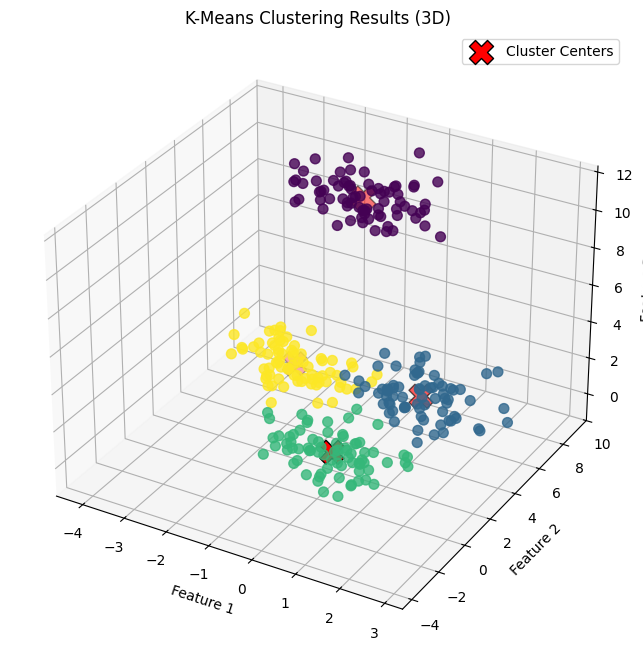

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points colored by cluster
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=cluster_labels, s=50, cmap='viridis', alpha=0.8)

# Plot the cluster centers
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], cluster_centers[:, 2], s=300, marker='X', c='red', edgecolor='black', label='Cluster Centers')

ax.set_title('K-Means Clustering Results (3D)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X, cluster_labels)
print(f"The average silhouette score is: {silhouette_avg}")

The average silhouette score is: 0.6572775442836907


O **Silhouette Score** é uma métrica usada para avaliar a qualidade da clusterização de dados, especialmente para algoritmos como o K-Means. Ele mede o quão similar um objeto é ao seu próprio cluster (coesão) em comparação com outros clusters (separação).

**Como ele é calculado para cada amostra?** Para cada ponto de dados i:



1.   **a(i) (Coesão):** É a distância média entre i e todos os outros pontos no mesmo cluster que i. Um valor pequeno para a(i) significa que i está bem agrupado com seus vizinhos de cluster.
2.   **b(i) (Separação):** É a menor distância média entre i e todos os pontos em qualquer outro cluster do qual i não faz parte. Um valor grande para b(i) significa que i está bem separado dos clusters vizinhos.

O silhouette score para uma amostra i é então calculado como: (b(i) - a(i)) / max(a(i), b(i)).

**Interpretação do Score:** O score médio da silhueta para todos os pontos de dados no conjunto de dados é uma medida da qualidade geral da clusterização.

*   **Valores próximos a +1:** Indicam que a amostra está bem agrupada dentro de seu próprio cluster e bem separada de outros clusters. Isso é o ideal.
*   **Valores próximos a 0:** Sugerem que a amostra está muito próxima da fronteira de decisão entre dois clusters, ou seja, ela poderia pertencer a qualquer um dos clusters ou a separação entre os clusters não é clara.
*   **Valores negativos (próximos a -1):** Indicam que a amostra pode ter sido atribuída ao cluster errado, pois está mais próxima dos pontos de um cluster vizinho do que dos pontos de seu próprio cluster.

Em resumo, um silhouette score mais alto geralmente indica uma melhor clusterização, com clusters mais densos e bem separados.

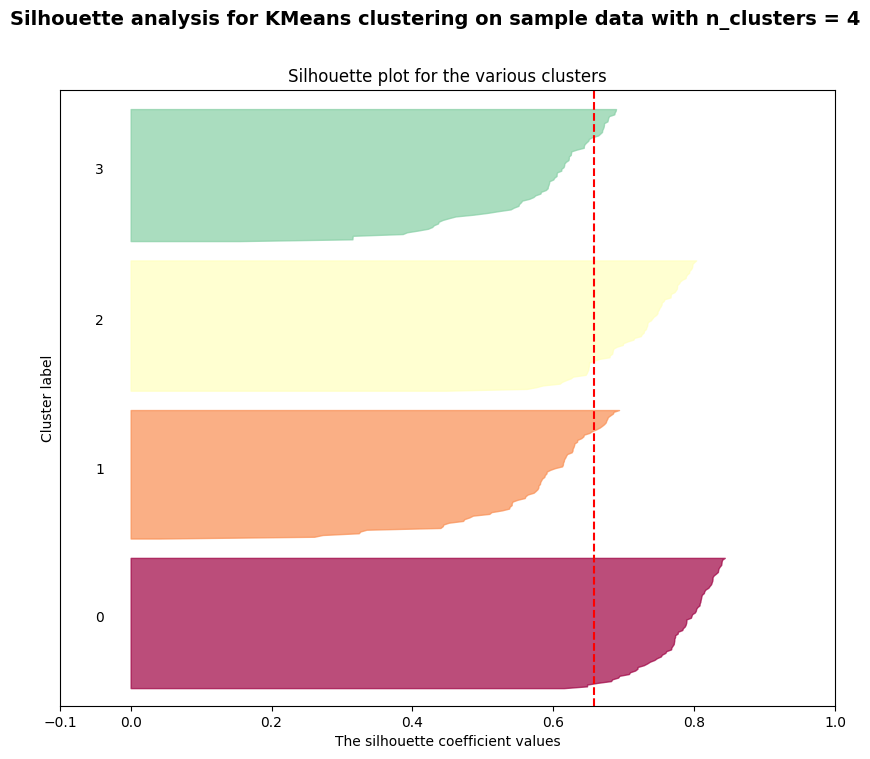

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_samples, silhouette_score

# Calculate silhouette scores for each sample
sample_silhouette_values = silhouette_samples(X, cluster_labels)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

y_lower = 10
for i in range(n_clusters):
    # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
    ith_cluster_silhouette_values = \
        sample_silhouette_values[cluster_labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.Spectral(float(i) / n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("Silhouette plot for the various clusters")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.suptitle(
    ("Silhouette analysis for KMeans clustering on sample data "
     "with n_clusters = %d" % n_clusters),
    fontsize=14, fontweight='bold'
)

plt.show()